# 引入所需的函式庫:
### MDAnalysis 讀取和處理原始的模擬軌跡數據，並提取出您感興趣的物理量。
### NumPy 用於高效地存儲和計算這些提取出來的數值數據（例如，將原子座標轉換為距離陣列），主要的目的是讓清單(list)可以和整數或浮點數進行四則運算。
### Matplotlib 將 NumPy 處理後的結果以視覺化的方式呈現出來，幫助研究人員理解數據中的模式和趨勢。

In [10]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

# 建立一個 Universe 去管理 trajectory檔(dcd file) 和 topology檔(pdb file):
### topology file: 描述第一幀(frame)時的分子或原子結構、原子間的鍵結、立場參數、電荷、質量等靜態信息。Ex: start_drudes.pdb
### trajectory file: 紀錄原子or分子隨時間(幀數)變化的動態座標(通常包含速度等)。Ex: FV_NVT.dcd
### u.guess_TopologyAttrs(context='default', to_guess=['elements']): 讓MDAnalysis嘗試自動推斷或「猜測」Universe 物件中缺失或未知的拓撲屬性(記得補這一行)。

In [11]:
u = mda.Universe("start_drudes.pdb", "FV_NVT.dcd")
u.guess_TopologyAttrs(context='default', to_guess=['elements'])

# 選取所需的幀數:
### 根據paper建立一個startFrame,在此Frame數之前的陰陽離子因為還在進行反應所以不穩定,而我們要節錄的部分則是後面陰陽離子穩定的地方(通常是總frame數的一半左右)。
### ( 所需的frame數 = 總frame數長 - startFrame前面不穩定的部分 )
### startFrame: 起始的幀數值，抓總幀數(u.trajectory.n_frames)約一半做分析，因為前面的部分還在平衡較不穩定，所以從大概一半的部分開始會比較好。
### len(u.trajectory): 代表整個 trajectory file(FV_NVT.dcd) 的總幀數，但由於前半段尚未完全平衡，因此我們只節錄後半段。

In [12]:
frameStart = 0 # (自己設定)
frameNeed = len(u.trajectory) - frameStart

#輸出結果來確認:
print(len(u.trajectory))
print(frameStart)
print(frameNeed)

2569
0
2569


# 設定每幾幀紀錄一次(avgfreq)並得出模擬所需的平均幀數(frameAverage):
### avgfreq: 用來定義紀錄幀數的頻率,如果 avgfreq = 2代表每2幀紀錄一次(類似拍幻燈片時，每幾秒拍一張相片),最後得出模擬需要的平均幀數--->frameAverage；avgfreq本身的用途就拿來"取樣"，因為整個系統的幀數很多，所以用此方法斟酌查看以減少cpu容量的消耗並提升計算效率。

In [13]:
avgfreq=2 # (自己設定)
frameAverage = int(frameNeed / avgfreq)

#輸出結果來確認:
print(frameAverage)

1284


# 設定要分割成多少個區間(bins)並選取需要的原子(cation & anion):
### u.trajectory[0].dimensions[2]: 為整個Z軸的總長度(dimensions[0、1、2]則分別代表x、y、z軸),trajectory[0]代表從第一幀數開始([0]為第一幀數、[1]為第二幀數以此類推)，其單位為埃(Å)。
### bins: 將u.trajectory[0].dimensions[2]分成幾等分的分母(類似將蛋糕要切幾塊)，這個值要自己去設定(bins越大精細度越高，但也不能太大)。
### dz: 是u.trajectory[0].dimensions[2]經bins分割後的每一小區間的長度(Å)，因為trajectory[0].dimensions[2]是原本的Z軸，所以用微分(dz)來表示。
### cation&anion: 用來儲存BMIM和trf中所選的碳原子(u.select_atoms)，分別是兩個AtomGroup。
### cation_counts&anion_counts: 用清單的方式去紀錄陰陽離子在整個u.trajectory[0].dimensions[2]各位置的數量分布(其本身是一種計數器，需要從預設值0開始記錄，以防數據不完整)。
## *請注意: BMI是陽離子,目前已知trf 和BF4 為陰離子

In [14]:
bins = 260 # (自己設定)
dz = u.trajectory[0].dimensions[2] / bins
cation = u.select_atoms("resname BMI and name C1")
anion  = u.select_atoms("resname trf and name Cf")

cation_counts = [0 for y in range(bins)]
anion_counts  = [0 for y in range(bins)]

#輸出結果來確認:
print(u.trajectory[0].dimensions[2])
print(dz)
# print(cation)
# print(anion)
# print(len(cation))
# print(len(anion))
# print(cation_counts)
# print(anion_counts)

260.422
1.001623


# 紀錄陰陽離子的Z軸位置:
### 1. for i in range(frameAverage): 利用for迴圈去紀錄在frameNeed中有幾個frameAverage，再用 "起始的幀數值(frameStart)+frameAverage的個數×平均頻率(avgfreq)" 去得知目前的幀數(frameCurrent)為何。只要目前的幀數(frameCurrent)大於該系統的總幀數len(u.trajectory)，則該迴圈停止(單位是幀數frame)。
### 2. u.trajectory[frameCurrent]: 根據整個FV_NVT.dcd(trajectory file)目前的幀數去進行調用(*u.trajectory[frameCurrent]只是一段語句，本身無法引入任何程式碼區塊)。
### 3. for atom_Cat in cation.positions & for atom_An in anion.positions: 利用for迴圈在cation.positions & cation.positions查找陰陽離子的位置。並且用2個清單分別為cation_counts & anion_counts來記錄陰陽離子的Z軸位置。
### 4. np.asfarray: 把原本的清單轉變成numpy浮點數陣列的格式來儲存，已用於後續和整數 (frameAverage、bins、len(cation),etc) 進行四則運算。

In [15]:
# print("陽離子的位置:\n", cation.positions)
# print("陰離子的位置:\n", anion.positions)

for i in range(frameAverage):
    frameCurrent = frameStart + i * avgfreq
    if frameCurrent >= len(u.trajectory):
        break
        
    u.trajectory[frameCurrent]
    for atom_Cat in cation.positions:
        cation_counts[int(atom_Cat[2] // dz)] += 1
        # print(atom_Cat)   # 把每一幀、每一位置的陽離子都列印出來(所以會列印出很多個)

    for atom_An in anion.positions:
        anion_counts[int(atom_An[2] // dz)] += 1
        # print(atom_An)   # 把每一幀、每一位置的陰離子都列印出來(所以會列印出很多個)

cation_counts=np.asarray(cation_counts)
anion_counts=np.asarray(anion_counts)
print("cation_counts:\n",cation_counts)
print("anion_counts:\n",anion_counts)

#輸出結果來確認:
# print(range(frameAverage))
# print(frameCurrent)
# print(u.trajectory[frameCurrent])
# print(dz)

cation_counts:
 [    0     0     0     0     0     0     0     0     0     0     0     0
     0     0   456  6185  4368  2986   894   527   734  1634  1194  2946
  4050  5090  2173  1200  2740  6694  9307 10402  8138  8251  8380  5990
  5510  5719  7411  7529  7292  7083  7113  7730  8067  7522  6749  6228
  6617  7850  7493  6872  6718  7035  7451  7869  7496  7227  6468  5901
  6158  7278  8163  7819  6945  6509  7404  7788  7286  6624  6684  6739
  6512  7161  7606  8165  7647  7572  7185  6310  6781  8141  7143  4363
  5052  8276  6437 11046  5774  4404 23768  6614  6675  2282     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     

# 歸一化: 
## 透過歸一化來得到平均每一幀、每一個區間內的「Z軸區間內」相對「整個系統(Z軸)」的離子比例
### 

In [16]:
# normalize 歸一化:
# print(cation)
# print(anion)
print("cation_counts:\n",cation_counts) # 陽離子清單 Before
# print(anion_counts) # 陰離子清單 Before
print("len(cation):\n",len(cation))
# print(len(cation_counts))
# print(len(anion))
# print(len(anion_counts))
print("frameAverage:\n",frameAverage)
print("bins:\n",bins)

# 我的理解:
cation_Ratio = cation_counts / len(cation) # 在所有被分析的幀數中，每個Z軸區間(bins)裡面的陽離子數量佔了所有Z軸上的陽離子總數之百分比。
# print("cation_Ratio:\n",cation_Ratio) 
cation_avgRatio = cation_Ratio / frameAverage # 平均每一幀中，位於Z軸區間(bins)內的陽離子數量佔「系統中(整個Z軸)所有陽離子總數」的比例。
# print("cation_avgRatio:\n",cation_avgRatio) 
cation_Density = cation_avgRatio / bins # 平均每一個Z軸區間(bins)的長度(單位:Å)裡，每一幀的Z軸區間(bins)裡其陽離子數和整個系統(總Z軸)的陽離子數之比例。
# print("cation_Density:\n",cation_Density) 
# 所以同理:
anion_Ratio = anion_counts / len(anion) # 在所有被分析的幀數中，每個Z軸區間(bins)裡面的陽離子數量佔了所有Z軸上的陰離子總數之百分比。
# print("anion_Ratio:\n",anion_Ratio) 
anion_avgRatio = anion_Ratio / frameAverage # 平均每一幀中，位於Z軸區間(bins)內的陰離子數量佔「系統中(整個Z軸)所有陰離子總數」的比例。
# print("anion_avgRatio:\n",anion_avgRatio) 
anion_Density = anion_avgRatio / bins # 平均每一個Z軸區間(bins)的長度(單位:Å)裡，每一幀的Z軸區間(bins)裡其陰離子數和整個系統(總Z軸)的陰離子數之比例。
# print("anion_Density:\n",anion_Density) 

# 學長姊的程式碼:
# cation_counts = cation_counts / len(cation) / frameAverage / bins
# anion_counts = anion_counts / len(anion) / frameAverage / bins


#輸出結果來確認:
# print(cation_counts) # 陽離子清單 After
# print(anion_counts) # 陰離子清單 After

cation_counts:
 [    0     0     0     0     0     0     0     0     0     0     0     0
     0     0   456  6185  4368  2986   894   527   734  1634  1194  2946
  4050  5090  2173  1200  2740  6694  9307 10402  8138  8251  8380  5990
  5510  5719  7411  7529  7292  7083  7113  7730  8067  7522  6749  6228
  6617  7850  7493  6872  6718  7035  7451  7869  7496  7227  6468  5901
  6158  7278  8163  7819  6945  6509  7404  7788  7286  6624  6684  6739
  6512  7161  7606  8165  7647  7572  7185  6310  6781  8141  7143  4363
  5052  8276  6437 11046  5774  4404 23768  6614  6675  2282     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     

In [17]:
print("\ncation:")
for i in range(len(cation_Density)):
    print( i , cation_Density[i])
print("\nanion:")
for i in range(len(anion_Density)):
    print( i ,anion_Density[i])


cation:
0 0.0
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
11 0.0
12 0.0
13 0.0
14 3.4148094895758442e-06
15 4.631709801102325e-05
16 3.2710280373831774e-05
17 2.236101126288042e-05
18 6.694823867721063e-06
19 3.946501317996644e-06
20 5.496645099448838e-06
21 1.223640067098011e-05
22 8.941409058231489e-06
23 2.2061466570812365e-05
24 3.0328900071890722e-05
25 3.8117062065660196e-05
26 1.6272765396597172e-05
27 8.986340762041695e-06
28 2.0518811406661874e-05
29 5.0128804217589264e-05
30 6.969656122693506e-05
31 7.78965971722981e-05
32 6.09423676012461e-05
33 6.178858135633837e-05
34 6.275461298825784e-05
35 4.485681763719147e-05
36 4.1262281332374794e-05
37 4.2827402348430386e-05
38 5.549814282290918e-05
39 5.638179966450995e-05
40 5.4606997364006716e-05
41 5.304187634795111e-05
42 5.326653486700216e-05
43 5.7887011742151925e-05
44 6.041067577282531e-05
45 5.632937934339803e-05
46 5.054067816918284e-05
47 4.6639108554996405e-05
48 4.955218068535826e-05
49 5.878564581835

# Matplotlib 作圖
### 1. 設定 z 軸位置: 透過z_positions = np.linspace(0, u.trajectory[0].dimensions[2], bins)建立z_positions和cation_counts的對應關係。
### 2. plt.figure: 用figsize=(A, B)去調整圖表的寬度和長度，其中A代表寬度，B為長度(單位為英吋)，通常會設置figsize=(10, 6)。
### 3. plt.plot: z_positions作為圖表上的X軸數據，代表離子在整個系統裡的空間位置； cation_Density作為圖表上的Y軸數據，代表該位置的歸一化密度值； label="Cation (BMI)"用於為這條線設定一個標籤，用於圖例； color='blue'用於設定線條顏色。
### 4. plt.xlim: 可參考z_positions的X軸起始值和結束值(0和u.trajectory[0].dimensions[2])。

列出前5個bin的位置(從0開始): [0.        1.0054903 2.0109806 3.016471  4.021961 ]
第0個bin的位置: 0.0
第1個bin的位置: 1.0054903
第2個bin的位置: 2.0109806
第3個bin的位置: 3.016471
第4個bin的位置: 4.021961


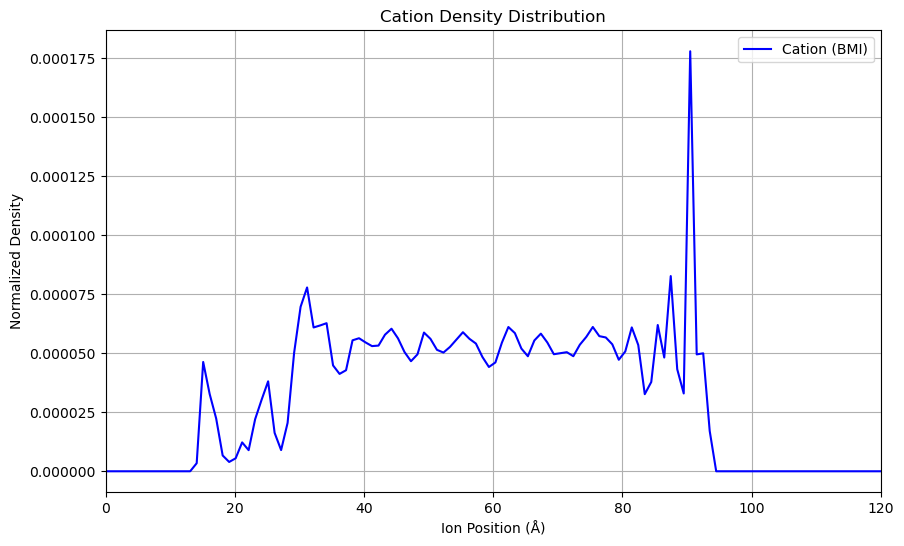

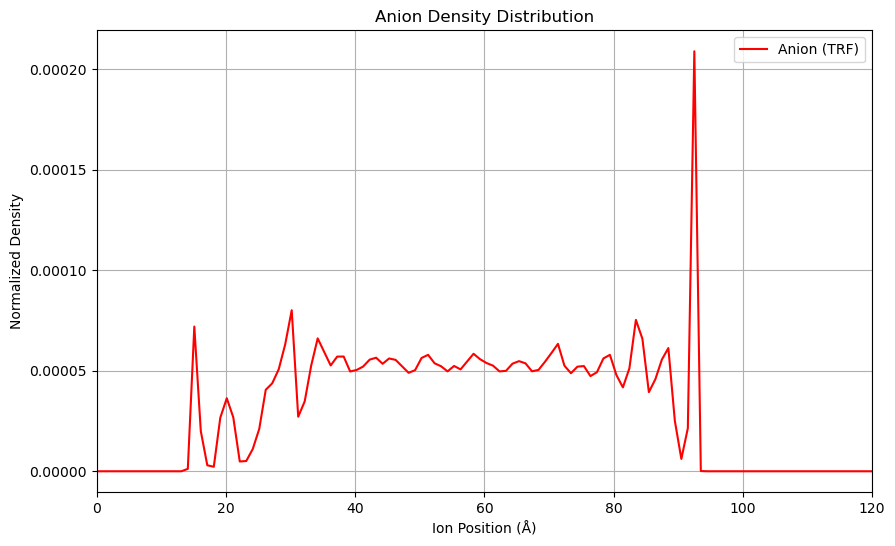

In [18]:
# matplotlib 陽離子密度圖
# 設定 z 軸位置
z_positions = np.linspace(0, u.trajectory[0].dimensions[2], bins) # 建立 z_positions 和 cation_counts 的對應關係
print("列出前5個bin的位置(從0開始):", z_positions[:5]) # 列出前五個bins的位置(包含第0個)
print("第0個bin的位置:", z_positions[0]) # 第0個bin的位置
print("第1個bin的位置:", z_positions[1]) # 第1個bin的位置
print("第2個bin的位置:", z_positions[2]) # 第2個bin的位置
print("第3個bin的位置:", z_positions[3]) # 第3個bin的位置
print("第4個bin的位置:", z_positions[4]) # 第5個bin的位置

# 繪製圖表
plt.figure(figsize=(10, 6)) # 創建一個新的圖表

# 正離子分布
plt.plot(z_positions, cation_Density, label="Cation (BMI)", color='blue') # 繪製陽離子密度

# 添加圖表標籤
plt.title("Cation Density Distribution")
plt.xlabel("Ion Position (Å)")
plt.ylabel("Normalized Density") # Y軸標籤與您之前的討論吻合
plt.legend() # 顯示圖例
plt.grid()   # 顯示網格
plt.xlim(0, 120) # 設定X軸範圍，可以根據實際模擬盒子大小調整
# 顯示圖表
plt.show()

# ----------------------------------------------------

# matplotlib 陰離子密度圖
# 設定 z 軸位置
z_positions = np.linspace(0, u.trajectory[0].dimensions[2], bins) # 這行也是重複的，但沒關係
# 繪製圖表
plt.figure(figsize=(10, 6)) # 創建另一個新的圖表

# 負離子分布
plt.plot(z_positions, anion_Density, label="Anion (TRF)", color='red') # 繪製陰離子密度

# 添加圖表標籤
plt.title("Anion Density Distribution")
plt.xlabel("Ion Position (Å)")
plt.ylabel("Normalized Density")
plt.legend()
plt.grid()
plt.xlim(0, 120) # 設定X軸範圍，可以根據實際模擬盒子大小調整
# 顯示圖表
plt.show()